<h1 style="color:#CC5500">Using Tesseract on The Spiritualist Newspaper (1869 - 1882) </h1>


<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/1/11/Toolbaricon_TesseractOCR.png" width="500" alt="PaddleOCR Logo">
</p>

This notebook was created in October 2025 for the National Library of Scotland (NLS) by Dr Joe Nockels, Digital Fellow. His related project, 'Recognising Text, Recognising Processes: eXplainable Automatic Text Recognition for Scottish Spiritualist Newspapers', was made possible through support from the NLS and Digital Humanities Institute (DHI), University of Sheffield. Images used of *The Spiritualist Newspaper* were first captured by the NLS Digitisation Unit in 2019, and made accessible as an open resource via the NLS Data Foundry (https://data.nls.uk/data/digitised-collections/spiritualist-newspapers/). In extracting text from these images, this project conducted technical trials of available OCR engines representative of current developmental and business structures, from open source applications to commercial LLMs. This also enabled improvements to be made on the NLS's inaccurate legacy OCR for *The Spiritualist*.

This research aimed to establish how far Automatic Text Recognition can coalesce with 'eXplainable' developmental principles, and the extent to which such principles can aid non-technical library users in their understanding of how AI reaches its transcription results. As such, the project's OCR experiments occurred alongside a thematic coding of each tool's public-facing documentation, including how-to guides, model cards and GitHub README files, as well as other grey literature such as technical papers produced by developmental consortia. This was done through a bespoke web crawler using in-built request delays to ensure server compliance, with eXplainable themes coded via NVIVO (https://lumivero.com/products/nvivo/).

The resultant OCR transcription data created through this experimentation is hosted via a comparative web dashboard developed by the DHI, linked to as part of this notebook series. This platform enables visual and curatorial comparisons between each AI-enabled tool's transcription results, alongside interactive hosting of *The Spiritualist* images used. The site also provides a clear link to each OCR engine notebook. Together, the project team hope that such a resource will enable curators, library users and Digital Humanists to move beyond a purely single-score quantitative benchmarking of OCR tools, such as Character and Word Error Rate (CER/WER), toward a more curatorial assessment of AI-enabled transcription outputs, especially considering that AI-enabled transcription is now being applied to qualitative domains such as text interpretation and summarisation.

As further context, this Jupyter Notebook follows previous NLS projects using the format to provide introductory analyses to Data Foundry collections, in line with the OpenGLAM movement and Collections as Data principles (Ames & Havens, 2020). As with these projects, this work was conducted to encourage, enable and support computational research methods on collections, as well as meeting FAIR principles for digital research (https://www.go-fair.org/fair-principles/). The need for human-readable explanations for digital cultural heritage research, with Jupyter Notebooks being a prime example, was also expressed during the 2025 Bridging Responsible AI Divides Cultural Heritage Forum at Senate House Library, where initial findings from this OCR work were first presented.

In following FAIR principles, please contact Joe Nockels at j.nockels@sheffield.ac.uk if any of the following code requires clarification, troubleshooting, or - indeed - you would like to make use of the web crawler used on OCR documentation, entitled 'GhostCrawler'. 

<h4>About The Spiritualist Newspaper</h4>

*The Spiritualist Newspaper*, first published by E.W. Allen (London) in 1869, forms a key source for how those interested in physical investigations and spiritual forces communicated with the deceased, argued about issues of the day, as well as publicised gatherings. The Newspaper followed a wake of spiritualist activity in Britain, directed by earlier 1850s American Transcendentalism and a more genral reaction to scientific naturalism. 

*The Spiritualist* was chosen as an OCR case study for several reasons: 

- Scottish spiritualist histories remain underrepresented, as Foot (2023) discusses. In our case, this partially results from historical detail being contained in heterogeneous and hard-to-transcribe material. This makes accurate OCR recognition more challenging, especially without requisite training data. With a fully searchable sample of 50 pages of *The Spiritualist* enabled through our OCR testing and reference, manually corrected, transcription, spiritualist activity outside of Scotland's Central Belt can be further explored. The trained reference model will also be applied to the entire collection as future work.

- In addition, Foot (2023: 73) suggests that seance mediums underwent 'automatic writing' to channel spiritual forces. The latter insight forms a neat parallel to charting the extent of unexplainable OCR processes in the current technical offering to libraries, as well as the potentially opaque behaviour and outputs of AI-enabled transcription models.

Alongside these two primary reasons, the project also aimed to provide metrics for the standardisation of OCR transcription at the NLS, with the Library currently undergoing a reassessment of its Foxit / ABBYY FineReader licence. The timings registered through the below trials, alongside the CER of outputs, were used as an evidence base for NLS decision-making around digital collection transcription.

 -  **Data format**: png. manuscript images, pre-processed (thresholding and additional cropping) in R Studio using Image Magick. 
 -  **Data creation process**: Convolutional Neural Network (CNN), Long-Short Term Memory, Optical Character Recognition.
 - **Data source**: https://data.nls.uk/data/digitised-collections/spiritualist-newspapers/, 50 pages of the first 1869 edition.

<h4> Table of Contents </h4>

- <a href = '#section 0'><h6>About the Model</h></a>
- <a href = '#section 1'><h6>Preparation</h6></a>
- <a href = '#section 2'><h6>OCR Processing</h6></a>
- <a href = '#section 3'><h6>Post-Processing</h6></a>

<h4>Citations</h4>

- Foot, M. (2023) *Modern Spiritualism and Scottish Art - Scots, Spirits and Seances, 1860 - 1940.* London: Bloomsbury.
- Ames, S., Havens, L. (2022) Exploring National Library of Scotland datasets with Jupyter Notebooks, *International Federation of Library Associations and Institutions*, 48(1): 50-56. https://doi.org/10.1177/03400352211065484

<a href = '#section 0'><h4>About the Model</h4></a>

With the NLS Digital Preservation Team trialling Tesseract as a possible low-threshold replacement for its ABBYY FineReader / Foxit PDF compressor licence (https://pdfexpert.com), this code was directed by such institutional concerns after contacting Lee Hibberd, Head of Digital Preservation. Tesseract's standard page segmentation models (psms) are tested, as well as its main English language model (https://github.com/tesseract-ocr/tesseract). These tests were conducted on an Apple Mac Silicon, with layout analysis performed through the OpenCV Graphics package (https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html). 

Tesseract was developed and maintained by the firm Hewlett-Packard, between 1984 and 1994, and became the first major commercial OCR package (Smith, 2007). Since 2006, the OCR engine has been supported by Google. Smith (2007: 629) maintains that OCR predating Tesseract failed “miserably on anything but the best quality print”, and that the software “had a significant lead in accuracy”. Nowadays, despite the introduction of LLMs, the open source OCR engine has a variety of uses based on text extraction: from text detection on mobile devices to classifying whether emails are spam. Tesseract, therefore, supports Automatic Text Recognition, and supports over 100 different languages out-of-the-box, with users also able to tailor models to particular datasets using accurate ground truth data. The software is alreadyo widely used within libraries, shown through National Library of Norway's experimentation using Tesseract for catalogue metadata extraction. 

Up until its second iteration, Tesseract was unable to handle colour, non-binarised, documents. With the integration of third-party libraries, this has since changed (Blanke et al., 2012: 662-663). Now, Tesseract is a robust text recognition tool and supports a range of input and output formats (Charlton, 2023: 9). 

**Citations** - 

- Charlton, A. (2023). OCR Report Final. University of Edinburgh Cultural Heritage Digitisation Service. doi: 10.7488/era/3652
- Blanke, T., Bryant, M., Hedges, M. (2012). Open source optical character recognition for historical research. *Journal of Documentation*. 68(5): 659-683. doi: 10.1108/00220411211256021
- de la Rosa, J. (2025). Machine learning at the National Library of Norway. In Lise Jaillant, Claire Warwick, Paul Gooding, Katherine Aske, Glen Layne-Worthey and J. Stephen Downie (eds.), *Navigating AI for Cultural Heritage Organisations*. UCL Press, 61 - 90. https://doi.org/10.14324/111.9781800088375
- Smith, R. (2007). An Overview of the Tesseract OCR Engine. Paper presented in *9th International Conference on Document Analysis and Recognition* (ICDAR 2007), 23-26 September, Curitiba, Brazil. pp. 629-633. doi: 10/1109/ICDAR.2007.4376991

<a href = '#section 1'><h4>Preparation</h4></a>

**Step 1** - In using Apple Mac Silicon hardware, importing Tesseract became a sensitive operation and relied on downgrading certain packages as part of the build. To ensure that no friction was caused between these downgrades and other OCR tests as part of the NLS fellowship, this notebook was ran within a dedicated Tesseract environment using conda. Therefore, if using a Mac Silicon, ensure that conda is activated before processing. For more advice on using conda, see: https://anaconda.org/anaconda/conda.

**Step 2** - After installing Open CV Graphics, PyTesseract and Pillow within your conda environment, import these models into the notebook. The former is required for layout analysis, with Pillow (PIL) enabling column splitting for newspaper layout extraction.

In [2]:
import cv2
import pytesseract
from PIL import Image

**Step 3** - With Tesseract including numerous page segmentation modes (psms), we first need to figure out which is best for recognising *The Spiritualist* layout. The following code tests Tesseract's three psms recommended for newspaper transcription and heterogenous layouts. Though rudimentary, the folliowing cell decides on a preferred psm by comparing the number of structured characters returned using each mode over a test jpg. stored locally. For now, we are less concerned with text extraction accuracy and more retaining the newspaper layout and reading order.

In [4]:
# run recommended psm modes against a test image and choose preferred mode based on number of extracted chars

test_image = '/Users/joenockels/Documents/NLS_Fellowship/nls_ocr_experimentation/Spiritualist_Sample/0001_p001.jpg' # replace with your own file path
img = cv2.imread(test_image)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert to RGB for processing
pil_img = Image.fromarray(img_rgb)

psm_modes = [3, 6, 7] # load the recommended page sementation modes
psm_scores = {}

for psm in psm_modes:
    config = f'--psm {psm}'
    text = pytesseract.image_to_string(pil_img, config=config)
    score = len(text.strip())
    psm_scores[psm] = (score, text)
    print(f"\n--- PSM {psm} ---\n{text[:500]}...\n[Score: {score} chars]\n{'-'*40}")

best_psm = max(psm_scores, key=lambda k: psm_scores[k][0]) # default to a preferred psm based on the amount of chars returned
print(f"\n Best PSM selected: {best_psm} (Score: {psm_scores[best_psm][0]} chars)\n")


--- PSM 3 ---
Che Bi

witnalist.

A RECORD OF THE PROGRESS OF THE, -BCIENCE AND ETHICS OF SPIRITUALISM.

“LONDON: TUESDAY, MARCH 15, 1870.

Published on the 15th of every
Month; Priee Threepenee.

No. 7.—Vor. I.
THE HANDLING OF RED-HOT COALS UNDER
SPIRIT INFLUENCE.

On one oceasion, in the presence of four other wit-
nesses, we saw the remarkable manifestation, so often |
mentioned in the journals devoted to Spiritualism, of
the handling of red-hot coals by Mr. D. D. Home while
he was in the trance state. The...
[Score: 13604 chars]
----------------------------------------

--- PSM 6 ---
Che Spiritua ist,
A RECORD OF THE PROGRESS OF THE, SCIENCE AND ETHICS OF SPIRITUALISM.
No Vey. LONDON: TUESDAY, MARCH 15, 1870. _ Eublished on tho 16th of very
THE HANDLING OF RED-HOT COALS UNDER burned himself. Home then held it within four or five} but it was quickly followed b 0
SPIRIT INFLUENCE. ; inches of Mr. Sanl’s and -Mr. Hurt’s hands, and they | table, but in different parts of aa ei eis me


**Step 4** - As a final preparation test, before constructing our OCR processing loop for the full 50 pg. *Spiritualist* sample, the following cell uses matplotlib to verify the preferred psm 3 - taken from the previous test. It first converts our image into an rgb format, before drawing the boundary box for each word detected with our 'best' psm. This enables a curatorial benchmarking of where CERs are likely to be seen based on layout analysis errors, especially considering our out-of-the-box approach.

In [5]:
import matplotlib.pyplot as plt

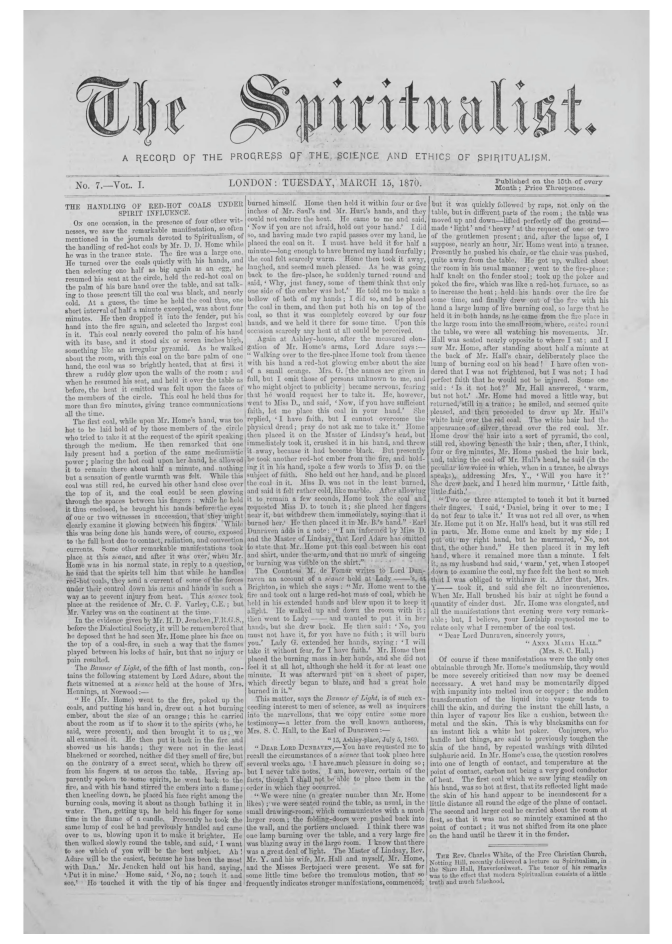

In [6]:
# Draw boundary boxes for each word as verification of psm

h, w, _ = img_rgb.shape

boxes = pytesseract.image_to_boxes(img_rgb, config=config)

img_boxes = img_rgb.copy()

for b in boxes.splitlines():
    b = b.split()
    char, x1, y1, x2, y2 = b[0], int(b[1]), int(b[2]), int(b[3]), int(b[4])
    y1_new = h - y1
    y2_new = h - y2
    top_left = (x1, y2_new)
    bottom_right = (x2, y1_new)
    cv2.rectangle(img_boxes, top_left, bottom_right, (0, 255, 0), 2)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

<a href = '#section 2'><h4>OCR Processing</h4></a>

**Step 1** - With some visual tests of the layout analysis options available in deploying Tesseract for *Spiritualist* transcription, this section constructs our looped function for batch newspaper processing. 

First, we need to import further packages for sequential processing, column extraction and ALTO XML construction - the latter needed for the interactive corresponding of *Spiritualist* images to Tesseract transcriptions as part of the DHI's hosting of fellowship outputs.
The time package also enables Tesseract's processing to be accounted for at page-level.

In [ ]:
import os
import re
import time # added based on Hibberd feedback, useful metric for NLS license decision-making 
import cv2
from PIL import Image
import pytesseract
import xml.etree.ElementTree as ET
from xml.dom import minidom

**Step 2** - Now, we need to establish the folder where our images reside, as well as the folder structure for .txt and ALTO XML exports (https://www.loc.gov/standards/alto/), the latter needed for interactive hosting of *Spiritualist* images via the DHI web dashboard. We also import our pre-configured psm 3, the preffered mode from our preparation tests.

In [ ]:
image_folder = '/Users/joenockels/Documents/NLS_Fellowship (2025)/Spiritualist_Images' # again, replace with your own file path
output_txt_file = 'tesseract_results.txt'
alto_output_folder = 'alto_output'
config = '--psm 3'

os.makedirs(alto_output_folder, exist_ok=True)

**Step 3** - With our packages imported and input - output folder structure set, we need to consturct the ALTO XML scaffold needed to ensure that whatever text Tesseract produces is coupled together with the image coordinates extracted. This will enable the DHI's interactive *Spiritualist* image hosting and IIIF compliance (https://iiif.io).

In [ ]:
def natural_sort_key(s): # ensure that column and word splitting is enabled to retain the document layout 
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def prettify_xml(elem): # indent this mark-up and ensure that it remains in a computer-readable utf format
    rough_string = ET.tostring(elem, 'utf-8')
    reparsed = minidom.parseString(rough_string)
    return reparsed.toprettyxml(indent="  ")

def extract_ocr_data(image_path): # run the OCR and layout detection
    img = cv2.imread(image_path)
    height, width, _ = img.shape
    ocr_result = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)

    blocks = []
    current_block = None
    for i, level in enumerate(ocr_result['level']):
        if level == 2:  # block
            if current_block:
                blocks.append(current_block)
            current_block = {
                'left': ocr_result['left'][i],
                'top': ocr_result['top'][i],
                'width': ocr_result['width'][i],
                'height': ocr_result['height'][i],
                'lines': []
            }
        elif level == 4:  # line
            if current_block is not None:
                current_block['lines'].append({
                    'left': ocr_result['left'][i],
                    'top': ocr_result['top'][i],
                    'width': ocr_result['width'][i],
                    'height': ocr_result['height'][i],
                    'words': []
                })
        elif level == 5:  # word
            if current_block and current_block['lines']:
                current_block['lines'][-1]['words'].append({
                    'text': ocr_result['text'][i],
                    'left': ocr_result['left'][i],
                    'top': ocr_result['top'][i],
                    'width': ocr_result['width'][i],
                    'height': ocr_result['height'][i]
                })
    if current_block:
        blocks.append(current_block)

    return {'image_width': width, 'image_height': height, 'blocks': blocks}

def create_alto_page(ocr_data):
    page_elem = ET.Element('alto', xmlns="http://www.loc.gov/standards/alto/ns-v4#")
    
    description = ET.SubElement(page_elem, 'Description')
    ET.SubElement(description, 'MeasurementUnit').text = 'pixel'
    
    layout = ET.SubElement(page_elem, 'Layout')
    page = ET.SubElement(layout, 'Page', width=str(ocr_data['image_width']),
                         height=str(ocr_data['image_height']),
                         PHYSICAL_IMG_NR="1")

    print_space = ET.SubElement(page, 'PrintSpace', height=str(ocr_data['image_height']),
                                width=str(ocr_data['image_width']), HPOS="0", VPOS="0")

    for block_idx, block in enumerate(ocr_data['blocks']):
        text_block = ET.SubElement(print_space, 'TextBlock', ID=f"block_{block_idx}",
                                   HPOS=str(block['left']), VPOS=str(block['top']),
                                   WIDTH=str(block['width']), HEIGHT=str(block['height']))
        for line_idx, line in enumerate(block['lines']):
            text_line = ET.SubElement(text_block, 'TextLine', ID=f"line_{block_idx}_{line_idx}",
                                      HPOS=str(line['left']), VPOS=str(line['top']),
                                      WIDTH=str(line['width']), HEIGHT=str(line['height']))
            for word_idx, word in enumerate(line['words']):
                ET.SubElement(text_line, 'String', ID=f"word_{block_idx}_{line_idx}_{word_idx}",
                              CONTENT=word['text'],
                              HPOS=str(word['left']), VPOS=str(word['top']),
                              WIDTH=str(word['width']), HEIGHT=str(word['height']))
    return prettify_xml(page_elem)

**Step 4** - We can now start our OCR loop. First, we establish an empty container for .txt ocr results and start the clock for Tesseract processing. We also ensure that the right files and formats are extracted from our local folder, in numerical order based on the filename. The following code also includes error handling, so the user knows on which page Tesseract potentially failed, as well as a printed notice of progress in processing. Our ALTO XML generator, based on the function above, is also made operational, before both file outputs are exported (one continous .txt file and page-level XML).

In [4]:
# OCR process 

ocr_results = {}
start_time = time.time()

image_files = sorted(
    [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], # locate files with these extensions in the folder, can be tailored to your own file types
    key=natural_sort_key
)

for filename in image_files:
    img_path = os.path.join(image_folder, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image {img_path}") # ensure error handling and that the processing error can be located, without stopping the loop entirely
        continue
    print(f"Processing {filename}...")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    text = pytesseract.image_to_string(pil_img, config=config)
    ocr_results[filename] = text.strip()

    # ALTO generation
    ocr_data = extract_ocr_data(img_path)
    alto_xml = create_alto_page(ocr_data)
    alto_file = os.path.join(alto_output_folder, os.path.splitext(filename)[0] + ".xml")
    with open(alto_file, 'w', encoding='utf-8') as f:
        f.write(alto_xml)

end_time = time.time()
total_time = end_time - start_time

# Save text output, both .txt and ALTO wrapper 

with open(output_txt_file, 'w', encoding='utf-8') as f:
    for fname in image_files:
        if fname in ocr_results:
            f.write(f"--- {fname} ---\n")
            f.write(ocr_results[fname] + "\n\n")

print(f"\nFinished processing {len(ocr_results)} images in {total_time:.2f} seconds")
print(f"Average time per page: {total_time / len(ocr_results):.2f} seconds")
print(f"OCR results saved to {output_txt_file}")
print(f"ALTO XML files saved to folder: {alto_output_folder}")

Processing 0001.png...
Processing 0002.png...
Processing 0003.png...
Processing 0004.png...
Processing 0005.png...
Processing 0006.png...
Processing 0007.png...
Processing 0008.png...
Processing 0009.png...
Processing 0010.png...
Processing 0011.png...
Processing 0012.png...
Processing 0013.png...
Processing 0014.png...
Processing 0015.png...
Processing 0016.png...
Processing 0017.png...
Processing 0018.png...
Processing 0019.png...
Processing 0020.png...
Processing 0021.png...
Processing 0022.png...
Processing 0023.png...
Processing 0024.png...
Processing 0025.png...
Processing 0026.png...
Processing 0027.png...
Processing 0028.png...
Processing 0029.png...
Processing 0030.png...
Processing 0031.png...
Processing 0032.png...
Processing 0033.png...
Processing 0034.png...
Processing 0035.png...
Processing 0036.png...
Processing 0037.png...
Processing 0038.png...
Processing 0039.png...
Processing 0040.png...
Processing 0041.png...
Processing 0042.png...
Processing 0043.png...
Processing 

**Summary** - This code has provided a pipeline for uploading and OCRing png. images of *The Spiritualist*, a 19th century newspaper taken from the National Library of Scotland's Data Foundry, using Tesseract OCR. We also provide an ALTO XML generator for IIIF compliant transcription outputs. The exported plain .txt export will be used to generate CERs externally from this notebook and offer a comparison to the other OCR engines tested as part of this notebook series.

For any further guidance, comments or questions - contact Dr Joe Nockels at j.nockels@sheffield.ac.uk.